# Assignment 3: Salary Prediction using Polynomial Regression

**Name:** AADISH ADLAK
**Registration Number:** 23BCE10681
**Application Number:** IN26010985
**Batch Number:** 9A
**Email:** adlakaadish@gmail.com

**Objective:** Build a Polynomial Regression model to predict employee salary based on position level, since the relationship between position level and salary is non-linear.

**Dataset:** [Position Salaries Dataset - Kaggle](https://www.kaggle.com/datasets/akram24/position-salaries)


## Task 1: Data Understanding (2 Marks)

- Load the dataset using Pandas
- Display the first five records
- Identify the Input Feature and Target Variable
- Display dataset info and summary statistics


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# For reproducibility
np.random.seed(42)

# Load dataset
df = pd.read_csv("data/Position_Salaries.csv")
df.head()

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000


In [2]:
# Display first five records
print("First 5 records of the dataset:")
df.head()

First 5 records of the dataset:


,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000


**Input Feature:** `Level` (numerical representation of the Position, ranges from 1 to 10)

**Target Variable:** `Salary` (the value we want to predict)

The `Position` column is a text label describing the same information as `Level`, so it is dropped and `Level` is used as the numeric input feature.


In [3]:
# Dataset information
print("Dataset Info:")
df.info()

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Position  10 non-null     str  
 1   Level     10 non-null     int64
 2   Salary    10 non-null     int64
dtypes: int64(2), str(1)
memory usage: 372.0 bytes


In [4]:
# Summary statistics
print("Summary Statistics:")
df.describe()

Summary Statistics:


,Level,Salary
count,10.00000,10.000000
mean,5.50000,249500.000000
std,3.02765,299373.883668
min,1.00000,45000.000000
25%,3.25000,65000.000000
50%,5.50000,130000.000000
75%,7.75000,275000.000000
max,10.00000,1000000.000000


## Task 2: Data Preprocessing (2 Marks)

- Check for missing values
- Select the appropriate feature(s) and target variable
- Split the dataset into 80% training and 20% testing


In [5]:
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Position    0
Level       0
Salary      0
dtype: int64


In [6]:
# Select feature (Level) and target (Salary)
X = df[['Level']].values   # Input feature (Position Level)
y = df['Salary'].values    # Target variable (Salary)

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (10, 1)
Target shape: (10,)


In [7]:
# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 8
Testing samples: 2


**Note:** This dataset only has 10 rows, so the 80/20 split leaves a very small test set (2 rows). This is expected for this classic teaching dataset and is called out in the observations below — a larger real-world salary dataset would give more reliable train/test evaluation.


## Task 3: Model Development (3 Marks)

1. Transform the input feature using Polynomial Features (Degree = 3)
2. Train a Polynomial Regression model
3. Predict salaries for the test dataset


In [8]:
# Transform input feature using Polynomial Features (Degree = 3)
poly_reg = PolynomialFeatures(degree=3)
X_train_poly = poly_reg.fit_transform(X_train)
X_test_poly = poly_reg.transform(X_test)

print("Original feature shape:", X_train.shape)
print("Polynomial feature shape (degree=3):", X_train_poly.shape)

Original feature shape: (8, 1)
Polynomial feature shape (degree=3): (8, 4)


In [9]:
# Train a Polynomial (Linear) Regression model on the transformed features
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

print("Model coefficients:", poly_model.coef_)
print("Model intercept:", poly_model.intercept_)

Model coefficients: [     0.         157144.24209541 -44274.84207263   3925.87219715]
Model intercept: -83661.20218580228


In [10]:
# Predict salaries for the test dataset
y_pred = poly_model.predict(X_test_poly)

comparison = pd.DataFrame({
    "Actual Salary": y_test,
    "Predicted Salary": np.round(y_pred, 2)
})
comparison

,Actual Salary,Predicted Salary
0,500000,606335.60
1,50000,84934.89


## Task 4: Model Evaluation (2 Marks)

Evaluate the model using MAE, MSE, and R2 Score, and visualize the results.


In [11]:
# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:,.2f}")
print(f"Mean Squared Error (MSE): {mse:,.2f}")
print(f"R2 Score: {r2:.4f}")

Mean Absolute Error (MAE): 70,635.25
Mean Squared Error (MSE): 6,263,853,282.86
R2 Score: 0.8763


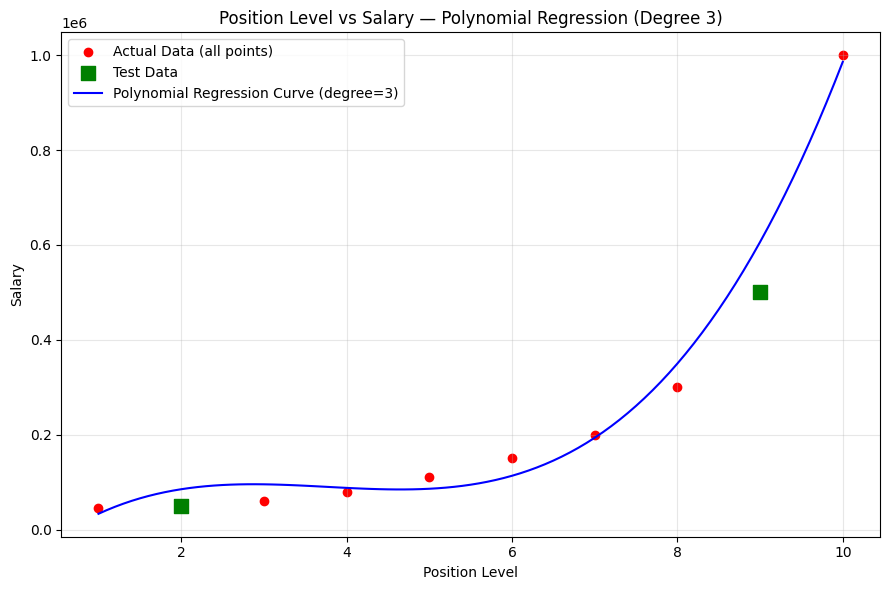

In [12]:
# Scatter plot of original data + Polynomial Regression curve
X_grid = np.arange(min(X.min(), 1), max(X.max(), 10) + 0.1, 0.1).reshape(-1, 1)
X_grid_poly = poly_reg.transform(X_grid)
y_grid_pred = poly_model.predict(X_grid_poly)

plt.figure(figsize=(9, 6))
plt.scatter(X, y, color='red', label='Actual Data (all points)')
plt.scatter(X_test, y_test, color='green', marker='s', s=90, label='Test Data', zorder=5)
plt.plot(X_grid, y_grid_pred, color='blue', label='Polynomial Regression Curve (degree=3)')
plt.title('Position Level vs Salary — Polynomial Regression (Degree 3)')
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('images/polynomial_regression_curve.png', dpi=150)
plt.show()

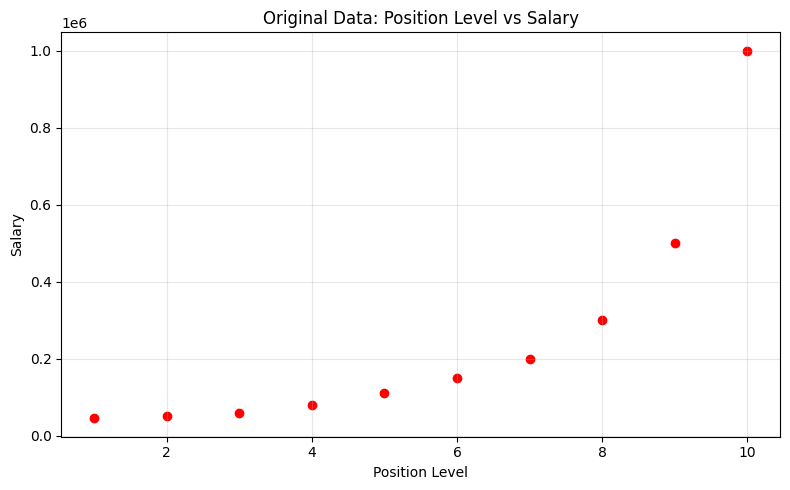

In [13]:
# Scatter plot of original data alone (for reference)
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='red')
plt.title('Original Data: Position Level vs Salary')
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('images/original_data_scatter.png', dpi=150)
plt.show()

### Observations

1. The Polynomial Regression curve (degree 3) closely follows the sharp, non-linear rise in salary at higher position levels, which a straight line (simple Linear Regression) would fail to capture.
2. Because the dataset has only 10 rows, the 80/20 split produces a very small test set, so the MAE, MSE, and R² values above should be interpreted as illustrative rather than statistically robust.
3. The largest prediction errors tend to occur near the highest position levels (e.g., CEO), where salary grows extremely fast (non-linearly) and small changes in level cause very large changes in salary.


## Task 5: Conclusion (1 Mark)

The Polynomial Regression model (degree 3) captured the non-linear relationship between an employee's position level and their salary far better than a straight-line fit would. Fitting the model showed that salary increases slowly at lower levels but accelerates sharply at senior levels (e.g., Partner, C-level, CEO), a pattern that Linear Regression — which assumes a constant rate of change — cannot represent well.

**Linear Regression vs Polynomial Regression:** Linear Regression fits a single straight line (`y = b0 + b1*x`) and assumes a constant relationship between the input and output. Polynomial Regression extends this by adding higher-degree terms (`x^2, x^3, ...`), allowing the model to fit curves and capture non-linear trends in the data while still being solved using linear regression techniques on the transformed features.

**Advantage for this dataset:** Since salary rises exponentially with seniority rather than linearly, Polynomial Regression provides a much closer, more accurate fit to the actual salary curve, significantly improving prediction accuracy for higher position levels compared to a simple linear model.
